In [2]:
from configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio


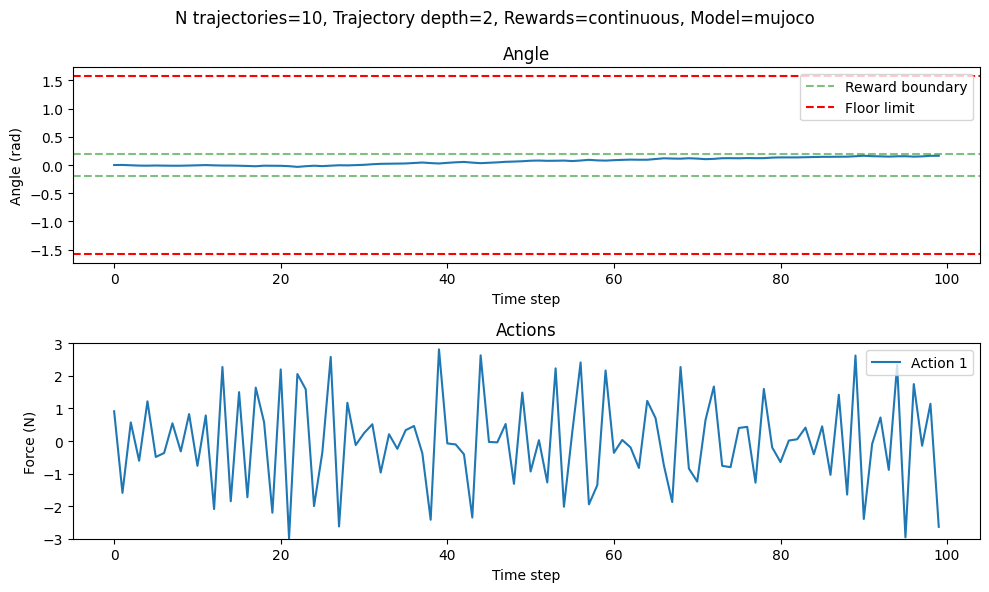

In [3]:
def simulate(bird, n_episodes, time_steps):
    """Simulate bird, possibly episodic SARSA."""

    simulation_data = {}

    for epi in range(n_episodes):
        episode_seed = 54 + epi
        np.random.seed(episode_seed)

        env = gym.make("InvertedPendulum-v5", render_mode="rgb_array", reset_noise_scale=0.01) 
        obs, _ = env.reset(seed=episode_seed)

        writer = imageio.get_writer("output.gif", fps=30)

        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.shape[0]

        observations = np.zeros((time_steps, obs_dim))
        actions = np.zeros((time_steps, act_dim))
        rewards = np.zeros(time_steps)

        observations[0] = obs  # store initial observation at time 0

        for t in range(time_steps):
            action = bird.mujoco_policy(env,obs)
            action = np.asarray(action).flatten()
            actions[t] = action

            obs, reward, done, truncated, info = env.step(action)
            observations[t] = obs
            rewards[t] = reward

            if epi == n_episodes - 1:
                frame = env.render()
                writer.append_data(np.asarray(frame).astype(np.uint8))

        writer.close()
        env.close()

        episode_data = {}

        for i in range(obs_dim):
            episode_data[f"state_{i+1}"] = observations[:, i]
        for i in range(act_dim):
            episode_data[f"action_{i+1}"] = actions[:, i]

        episode_data["reward"] = rewards

        simulation_data[f"episode_{epi+1}"] = episode_data

    return simulation_data



# Simulate the bird
planning_width = 10 # how many trajectories to simulate
n_planning = 2 # how deep the rolout of each trajectory is
reward_type='continuous' # rewards can be 'discrete' or 'continuous'
model_type='mujoco' # model can be 'mujoco' or 'linear_full' or 'linear_reduced_<int>' where <int> is the rank of the model

bird = MPCShittyBird(n_actions = 10, planning_width=planning_width, n_planning=n_planning, reward_type=reward_type, model_type=model_type) 

# Simulate the bird
simulation_data = simulate(bird, n_episodes=1, time_steps=100)

episode1 = simulation_data["episode_1"]

angle = episode1["state_1"]

# Gather all action dimensions into a 2D array (time_steps, act_dim)
action_keys = sorted([k for k in episode1 if k.startswith("action_")])  # sorted for order
actions = np.vstack([episode1[k] for k in action_keys]).T

plt.figure(figsize=(10, 6))
plt.suptitle(f'N trajectories={planning_width}, Trajectory depth={n_planning}, Rewards={reward_type}, Model={model_type}', fontsize=12)

# Plot the angle
plt.subplot(2, 1, 1)
plt.plot(angle)
plt.title('Angle')
plt.xlabel('Time step')
plt.ylabel('Angle (rad)')
plt.axhline(y=-0.2, color='g', linestyle='--', alpha=0.5, label='Reward boundary')
plt.axhline(y=0.2, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=-1.573, color='r', linestyle='--', label='Floor limit')
plt.axhline(y=1.573, color='r', linestyle='--')
plt.legend()

# Plot the actions
plt.subplot(2, 1, 2)
plt.plot(actions)
plt.title('Actions')
plt.xlabel('Time step')
plt.ylabel('Force (N)')
plt.ylim(-3, 3)
plt.legend([f'Action {i+1}' for i in range(actions.shape[1])], loc='upper right')

plt.tight_layout()
plt.show()

